<a href="https://colab.research.google.com/github/Shinyhunter95/Masters-Project/blob/main/AR(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

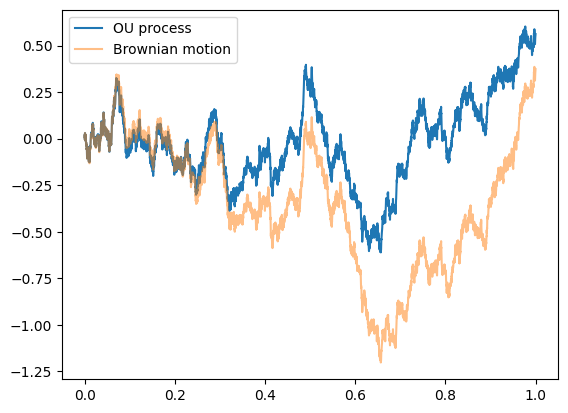

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 1.0
N = 5000
c = 10.0

dt = T / N
t = np.linspace(0, T, N + 1)

# Brownian increments
dW = np.sqrt(dt) * np.random.randn(N)

# Brownian path
W = np.zeros(N + 1)
W[1:] = np.cumsum(dW)

# OU process via stochastic convolution
X = np.zeros(N + 1)

for i in range(1, N + 1):
    kernel = np.exp(-c * (t[i] - t[:i]))
    X[i] = np.sum(kernel * dW[:i])

# Plot
plt.plot(t, X, label="OU process")
plt.plot(t, W, alpha=0.5, label="Brownian motion")
plt.legend()
plt.show()

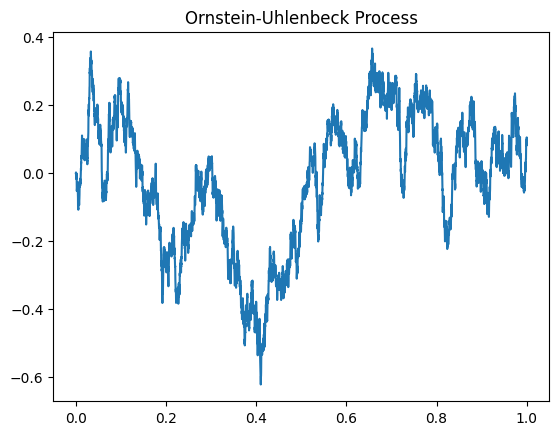

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 1.0
N = 5000
c = 10.0

dt = T / N
t = np.linspace(0, T, N + 1)

# Brownian increments
dW = np.sqrt(dt) * np.random.randn(N)

# Simulate OU process
X = np.zeros(N + 1)

for i in range(N):
    X[i+1] = X[i] - c * X[i] * dt + dW[i]

# Plot
plt.plot(t, X)
plt.title("Ornstein-Uhlenbeck Process")
plt.show()

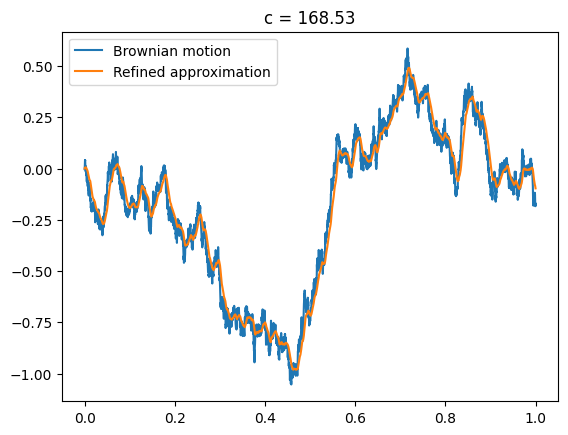

sup |W(t)| = 1.0532643726378428
sup |X(t)| = 0.9817904806731016


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

N = 5000

lambda_n = N**(-0.4)
rho = 1 - lambda_n

c = N * np.log(1 / rho)

# time grid
t = np.linspace(0, 1, N)

# ---------------------------------
# Brownian motion
# ---------------------------------

dW = np.random.normal(0, 1/np.sqrt(N), N)
W = np.cumsum(dW)

# ---------------------------------
# OU correction term
# ---------------------------------

OU_term = np.zeros(N)

for k in range(N):

    tk = t[k]

    kernel = np.exp(-c * (tk - t[:k+1]))

    OU_term[k] = np.sum(kernel * dW[:k+1])

# ---------------------------------
# Approximation process
# ---------------------------------

X = W - OU_term

# ---------------------------------
# Plot
# ---------------------------------

plt.plot(t, W, label='Brownian motion')
plt.plot(t, X, label='Refined approximation')

plt.legend()
plt.title(f'c = {c:.2f}')
plt.show()

print("sup |W(t)| =", np.max(np.abs(W)))
print("sup |X(t)| =", np.max(np.abs(X)))